<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Agricultura_Inteligente_con_Redes_Bayesianas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q pgmpy==0.1.25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.6 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from google.colab import files

from pgmpy.models import BayesianNetwork
from pgmpy.estimators import HillClimbSearch
from pgmpy.estimators import BicScore
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination

In [5]:
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

df.head()

Saving Crop_recommendation.csv to Crop_recommendation.csv


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
print(df.shape)

df.info()

df.describe()

(2200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [7]:
columnas = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

for c in columnas:

    df[c] = pd.qcut(
        df[c],
        q=3,
        labels=["Bajo","Medio","Alto"]
    )

In [8]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,Alto,Medio,Medio,Bajo,Medio,Medio,Alto,rice
1,Alto,Medio,Medio,Bajo,Medio,Alto,Alto,rice
2,Medio,Medio,Medio,Bajo,Medio,Alto,Alto,rice
3,Alto,Bajo,Medio,Medio,Medio,Alto,Alto,rice
4,Alto,Medio,Medio,Bajo,Medio,Alto,Alto,rice


In [9]:
hc = HillClimbSearch(df)

modelo = hc.estimate(
    scoring_method=BicScore(df)
)

print(modelo.edges())

  0%|          | 0/1000000 [00:00<?, ?it/s]

[('ph', 'label'), ('label', 'K'), ('label', 'humidity'), ('label', 'P'), ('label', 'rainfall'), ('label', 'N'), ('label', 'temperature')]


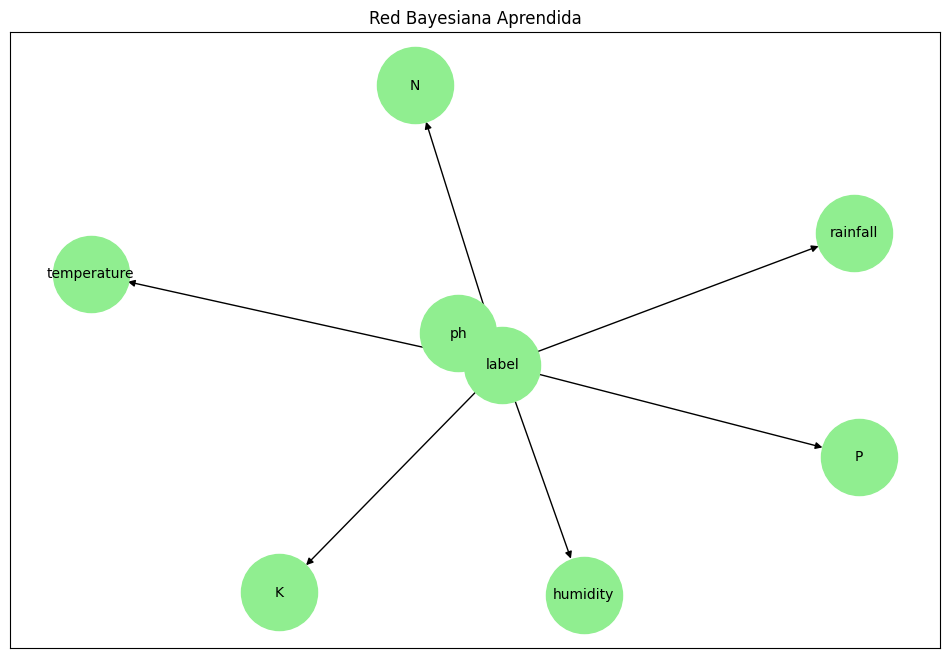

In [10]:
G = nx.DiGraph()

G.add_edges_from(modelo.edges())

plt.figure(figsize=(12,8))

pos = nx.spring_layout(G, seed=1)

nx.draw_networkx(

    G,

    pos,

    node_size=3000,

    node_color="lightgreen",

    arrows=True,

    font_size=10

)

plt.title("Red Bayesiana Aprendida")

plt.show()

In [11]:
modelo = BayesianNetwork(modelo.edges())

modelo.fit(

    df,

    estimator=BayesianEstimator,

    prior_type="BDeu"

)

In [12]:
inferencia = VariableElimination(modelo)

In [13]:
resultado = inferencia.query(

    variables=["label"],

    evidence={

        "N":"Alto",

        "P":"Medio",

        "K":"Alto",

        "temperature":"Alto",

        "humidity":"Alto",

        "ph":"Medio",

        "rainfall":"Alto"

    }

)

print(resultado)

+--------------------+--------------+
| label              |   phi(label) |
+====================+==============+
| label(apple)       |       0.0000 |
+--------------------+--------------+
| label(banana)      |       0.0001 |
+--------------------+--------------+
| label(blackgram)   |       0.0000 |
+--------------------+--------------+
| label(chickpea)    |       0.0000 |
+--------------------+--------------+
| label(coconut)     |       0.0000 |
+--------------------+--------------+
| label(coffee)      |       0.0000 |
+--------------------+--------------+
| label(cotton)      |       0.0000 |
+--------------------+--------------+
| label(grapes)      |       0.0000 |
+--------------------+--------------+
| label(jute)        |       0.0006 |
+--------------------+--------------+
| label(kidneybeans) |       0.0000 |
+--------------------+--------------+
| label(lentil)      |       0.0000 |
+--------------------+--------------+
| label(maize)       |       0.0000 |
+-----------

In [14]:
cultivos = resultado.state_names["label"]

prob = resultado.values

df_resultado = pd.DataFrame({

    "Cultivo":cultivos,

    "Probabilidad":prob

})

df_resultado = df_resultado.sort_values(

    "Probabilidad",

    ascending=False

)

df_resultado.head(10)

,Cultivo,Probabilidad
17,papaya,9.992362e-01
8,jute,5.880974e-04
1,banana,1.104316e-04
15,muskmelon,5.345727e-05
20,rice,1.143677e-05
5,coffee,3.561170e-07
21,watermelon,1.918923e-08
14,mungbean,1.443394e-08
4,coconut,1.050117e-08
0,apple,8.942575e-09


In [15]:
mejor = df_resultado.iloc[0]

print("Cultivo recomendado:")

print(mejor["Cultivo"])

print("Probabilidad:")

print(round(mejor["Probabilidad"]*100,2),"%")

Cultivo recomendado:
papaya
Probabilidad:
99.92 %


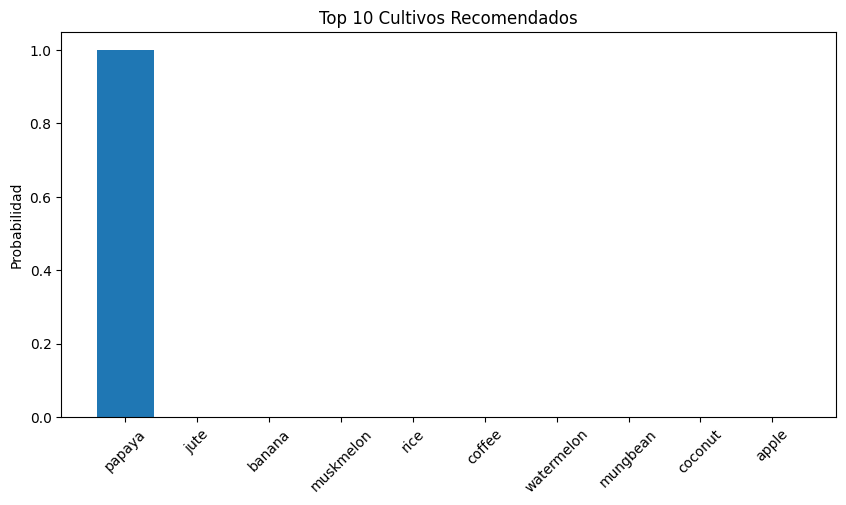

In [16]:
top = df_resultado.head(10)

plt.figure(figsize=(10,5))

plt.bar(

    top["Cultivo"],

    top["Probabilidad"]

)

plt.xticks(rotation=45)

plt.ylabel("Probabilidad")

plt.title("Top 10 Cultivos Recomendados")

plt.show()

In [17]:
resultado = inferencia.query(
    variables=["label"],
    evidence={

        "N":"Alto",

        "P":"Medio",

        "K":"Medio",

        "temperature":"Medio",

        "humidity":"Alto",

        "ph":"Medio",

        "rainfall":"Alto"
    }
)

print(resultado)

+--------------------+--------------+
| label              |   phi(label) |
+====================+==============+
| label(apple)       |       0.0000 |
+--------------------+--------------+
| label(banana)      |       0.0000 |
+--------------------+--------------+
| label(blackgram)   |       0.0000 |
+--------------------+--------------+
| label(chickpea)    |       0.0000 |
+--------------------+--------------+
| label(coconut)     |       0.0000 |
+--------------------+--------------+
| label(coffee)      |       0.0006 |
+--------------------+--------------+
| label(cotton)      |       0.0000 |
+--------------------+--------------+
| label(grapes)      |       0.0000 |
+--------------------+--------------+
| label(jute)        |       0.9806 |
+--------------------+--------------+
| label(kidneybeans) |       0.0000 |
+--------------------+--------------+
| label(lentil)      |       0.0000 |
+--------------------+--------------+
| label(maize)       |       0.0000 |
+-----------

In [18]:
cultivos = resultado.state_names["label"]

prob = resultado.values

df_resultado = pd.DataFrame({

    "Cultivo":cultivos,

    "Probabilidad":prob

})

df_resultado = df_resultado.sort_values(

    "Probabilidad",

    ascending=False

)

df_resultado.head(10)

,Cultivo,Probabilidad
8,jute,9.806375e-01
20,rice,1.873566e-02
5,coffee,6.017024e-04
17,papaya,2.171619e-05
4,coconut,2.554389e-06
6,cotton,3.533319e-07
19,pomegranate,1.850659e-07
11,maize,1.813104e-07
14,mungbean,8.313019e-08
1,banana,1.539349e-08


In [19]:
mejor = df_resultado.iloc[0]

print("Cultivo recomendado:")

print(mejor["Cultivo"])

print("Probabilidad:")

print(round(mejor["Probabilidad"]*100,2),"%")

Cultivo recomendado:
jute
Probabilidad:
98.06 %


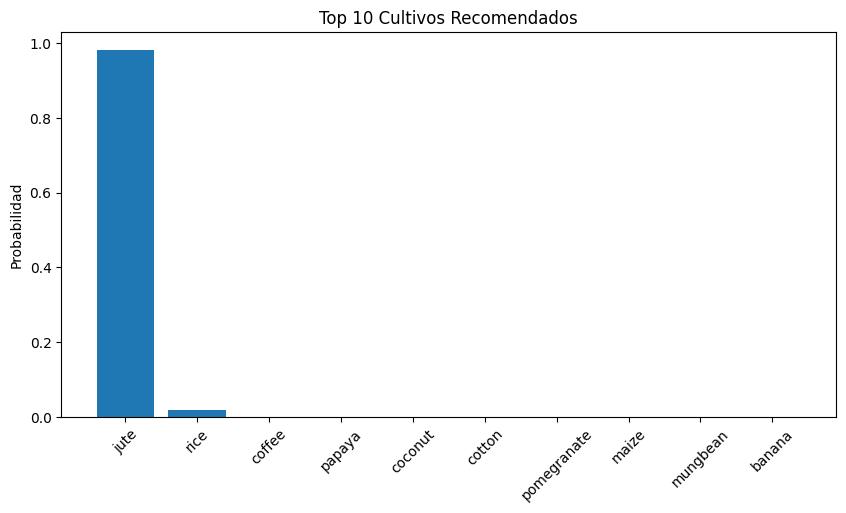

In [20]:
top = df_resultado.head(10)

plt.figure(figsize=(10,5))

plt.bar(

    top["Cultivo"],

    top["Probabilidad"]

)

plt.xticks(rotation=45)

plt.ylabel("Probabilidad")

plt.title("Top 10 Cultivos Recomendados")

plt.show()

In [21]:
resultado = inferencia.query(
    variables=["label"],
    evidence={

        "N":"Alto",

        "P":"Alto",

        "K":"Medio",

        "temperature":"Alto",

        "humidity":"Medio",

        "ph":"Medio",

        "rainfall":"Medio"

    }
)

print(resultado)

+--------------------+--------------+
| label              |   phi(label) |
+====================+==============+
| label(apple)       |       0.0000 |
+--------------------+--------------+
| label(banana)      |       0.9797 |
+--------------------+--------------+
| label(blackgram)   |       0.0178 |
+--------------------+--------------+
| label(chickpea)    |       0.0000 |
+--------------------+--------------+
| label(coconut)     |       0.0000 |
+--------------------+--------------+
| label(coffee)      |       0.0000 |
+--------------------+--------------+
| label(cotton)      |       0.0003 |
+--------------------+--------------+
| label(grapes)      |       0.0003 |
+--------------------+--------------+
| label(jute)        |       0.0000 |
+--------------------+--------------+
| label(kidneybeans) |       0.0000 |
+--------------------+--------------+
| label(lentil)      |       0.0000 |
+--------------------+--------------+
| label(maize)       |       0.0001 |
+-----------

In [22]:
cultivos = resultado.state_names["label"]

prob = resultado.values

df_resultado = pd.DataFrame({

    "Cultivo":cultivos,

    "Probabilidad":prob

})

df_resultado = df_resultado.sort_values(

    "Probabilidad",

    ascending=False

)

df_resultado.head(10)

,Cultivo,Probabilidad
1,banana,0.979660
2,blackgram,0.017810
18,pigeonpeas,0.001814
7,grapes,0.000299
6,cotton,0.000262
11,maize,0.000091
5,coffee,0.000034
10,lentil,0.000015
17,papaya,0.000012
12,mango,0.000001


In [23]:
mejor = df_resultado.iloc[0]

print("Cultivo recomendado:")

print(mejor["Cultivo"])

print("Probabilidad:")

print(round(mejor["Probabilidad"]*100,2),"%")

Cultivo recomendado:
banana
Probabilidad:
97.97 %


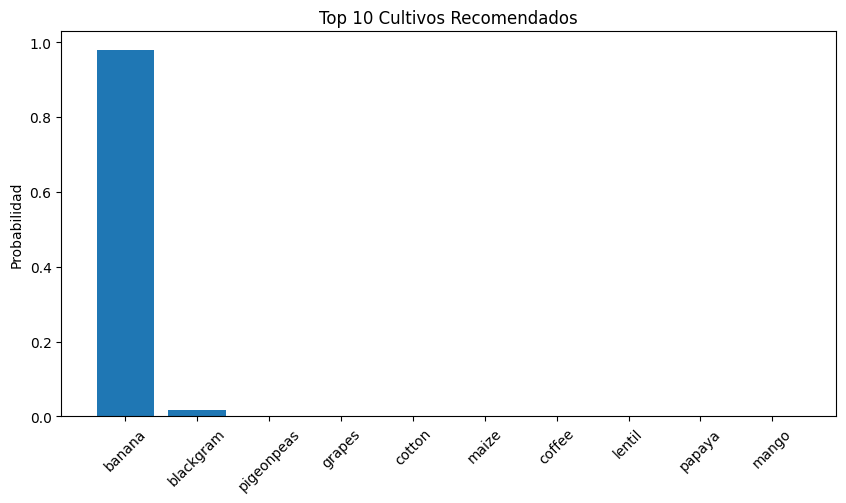

In [24]:
top = df_resultado.head(10)

plt.figure(figsize=(10,5))

plt.bar(

    top["Cultivo"],

    top["Probabilidad"]

)

plt.xticks(rotation=45)

plt.ylabel("Probabilidad")

plt.title("Top 10 Cultivos Recomendados")

plt.show()

In [25]:
# Limpia el estado interno de widgets en el entorno de Colab
from google.colab import output
output.clear()
